In [76]:
import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from keras.layers import Activation, Dense, Dropout, Input, LSTM
from keras.models import Sequential
from keras.utils import pad_sequences
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error as mse
from sklearn.model_selection import train_test_split
np.random.seed(1234)
PYTHONHASHSEED = 0
pd.set_option('display.float_format', lambda x: '%.5f' % x)
from tensorflow.keras.layers import RepeatVector, TimeDistributed


In [77]:
from google.colab import files
uploaded = files.upload()
fname = list(uploaded.keys())[0]

df = pd.read_csv(fname)
df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.sort_values("Datetime").reset_index(drop=True)
no2 = df.copy()
df.head()


Saving cleanedno2newusdc 2.csv to cleanedno2newusdc 2 (2).csv


,Date,Time,NO2(GT),PT08.S4(NO2),Temperature (C),Relative Humidity,Absolute Humidity,Datetime
0,2004-03-10,18:00:00,0.32840,0.51304,0.33333,0.49937,0.28007,2004-03-10 18:00:00
1,2004-03-10,19:00:00,0.26627,0.45324,0.32688,0.48428,0.26428,2004-03-10 19:00:00
2,2004-03-10,20:00:00,0.33136,0.45144,0.29677,0.56352,0.27635,2004-03-10 20:00:00
3,2004-03-10,21:00:00,0.35503,0.46448,0.27742,0.63899,0.29419,2004-03-10 21:00:00
4,2004-03-10,22:00:00,0.33728,0.42221,0.28172,0.63396,0.29522,2004-03-10 22:00:00


In [78]:
def plot_lr_data(mu, prediction_horizon, number_of_samples, tp_pred, yp_pred, time_series, sensor_values, first=True):
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.suptitle("Linear baseline prediction vs sensor", fontsize=18, fontweight="bold")

    if first:
        i0, i1 = 0, 200
    else:
        i0, i1 = max(0, number_of_samples - 200), number_of_samples

    ax.plot(tp_pred[i0:i1], yp_pred[i0:i1], label="Predicted")
    ax.plot(time_series.iloc[i0:i1, 0], sensor_values.iloc[i0:i1, 0], label="Sensor")

    ax.set_xlabel("time")
    ax.set_ylabel("normalized value")
    ax.legend()
    plt.show()


In [79]:
"""convert datetime to epoch/unix time and add as new column"""
no2["Datetime"] = pd.to_datetime(no2["Datetime"])
no2["unix"] = no2["Datetime"].apply(lambda x: x.timestamp())

no2.head()



,Date,Time,NO2(GT),PT08.S4(NO2),Temperature (C),Relative Humidity,Absolute Humidity,Datetime,unix
0,2004-03-10,18:00:00,0.32840,0.51304,0.33333,0.49937,0.28007,2004-03-10 18:00:00,1078941600.00000
1,2004-03-10,19:00:00,0.26627,0.45324,0.32688,0.48428,0.26428,2004-03-10 19:00:00,1078945200.00000
2,2004-03-10,20:00:00,0.33136,0.45144,0.29677,0.56352,0.27635,2004-03-10 20:00:00,1078948800.00000
3,2004-03-10,21:00:00,0.35503,0.46448,0.27742,0.63899,0.29419,2004-03-10 21:00:00,1078952400.00000
4,2004-03-10,22:00:00,0.33728,0.42221,0.28172,0.63396,0.29522,2004-03-10 22:00:00,1078956000.00000


In [62]:
"""Setup data and train linear regression model"""
time_series = pd.DataFrame(no2.unix)
sensor_values = pd.DataFrame(no2.filter(["PT08.S4(NO2)"]))

number_of_samples = len(time_series)
prediction_horizon = 24 * 3600
mu = 0.9

tp_pred = np.zeros(number_of_samples - 1)
yp_pred = np.zeros(number_of_samples - 1)

for i in range(2, number_of_samples + 1):
    ts_tmp = time_series[0:i]
    ys_tmp = sensor_values[0:i]
    ns = len(ys_tmp)

    weights = np.ones(ns) * mu
    for k in range(ns):
        weights[k] = weights[k] ** k
    weights = np.flip(weights, 0)

    lm_tmp = LinearRegression()
    model_tmp = lm_tmp.fit(ts_tmp, ys_tmp, sample_weight=weights)

    m_tmp = model_tmp.coef_
    q_tmp = model_tmp.intercept_

    tp = time_series.iloc[i-1, 0] + prediction_horizon
    yp = m_tmp * tp + q_tmp

    tp_pred[i-2] = tp
    yp_pred[i-2] = yp.item()


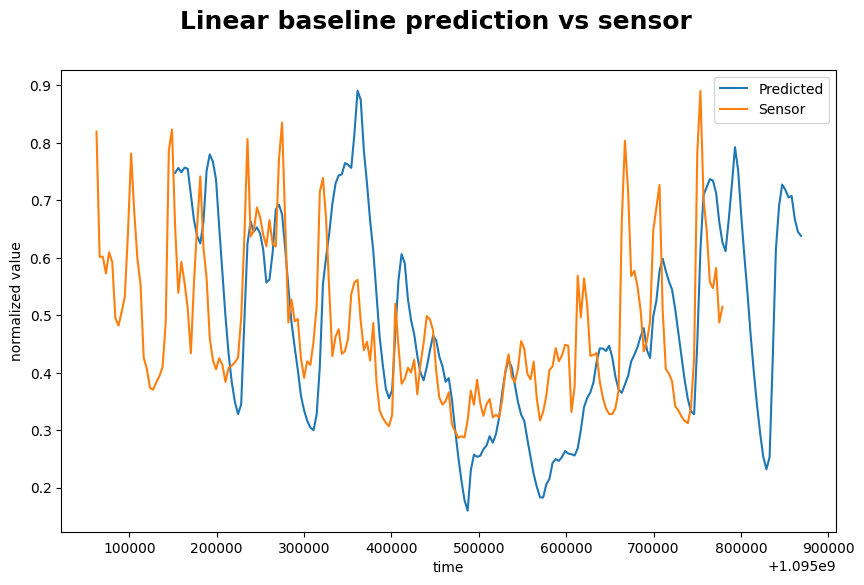

In [80]:
mid = number_of_samples // 2
tp_mid = tp_pred[mid - 200: mid + 200]
yp_mid = yp_pred[mid - 200: mid + 200]
ts_mid = time_series.iloc[mid - 200: mid + 200]
sv_mid = sensor_values.iloc[mid - 200: mid + 200]

plot_lr_data(mu, prediction_horizon, number_of_samples, tp_mid, yp_mid, ts_mid, sv_mid, first=True)


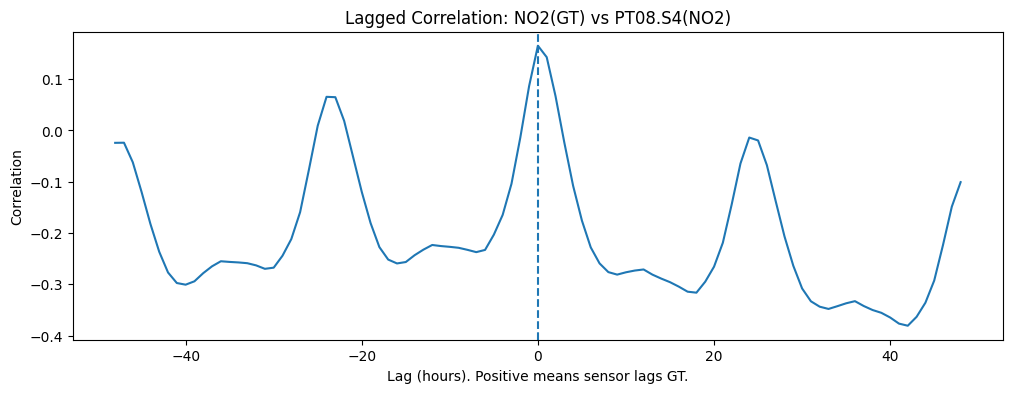

Best lag (hours): 0  Corr: 0.1653188764860554


In [64]:

GT_COL = "NO2(GT)"
SENSOR_COL = "PT08.S4(NO2)"

if GT_COL in no2.columns and SENSOR_COL in no2.columns:
    max_lag = 48
    lags = range(-max_lag, max_lag + 1)

    a = no2[GT_COL].astype(float)
    b = no2[SENSOR_COL].astype(float)

    cors = []
    for L in lags:
        cors.append(a.corr(b.shift(L)))

    plt.figure(figsize=(12,4))
    plt.plot(list(lags), cors)
    plt.axvline(0, linestyle="--")
    plt.title("Lagged Correlation:NO2(GT) vsPT08.S4(NO2)")
    plt.xlabel("Lag (in hours) Positive sensor lags GT.")
    plt.ylabel("Correlation")
    plt.show()

    best_lag = list(lags)[int(np.nanargmax(cors))]
    print("Best lag (hours):", best_lag, " Corr:", float(np.nanmax(cors)))
else:
    print("GT column not found. We are lagged correlation.")


In [65]:

def plot_loss(history):
    plt.figure(figsize=(8,4))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.title("Loss Over Time")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

def plot_actual_vs_pred(y_true, y_pred, title="Actual vs Predicted", last_n=200):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    plt.figure(figsize=(12,4))
    plt.plot(y_true[-last_n:], label="Actual", linewidth=2)
    plt.plot(y_pred[-last_n:], label="Predicted", linestyle="--")
    plt.title(title + f" (Last {last_n})")
    plt.xlabel("Index")
    plt.ylabel("Value")
    plt.legend()
    plt.show()

def plot_rolling_rmse(y_true, y_pred, window=24, title="Rolling RMSE"):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    err = y_pred - y_true
    rolling = pd.Series(err).rolling(window).apply(lambda x: np.sqrt(np.mean(x**2)), raw=True)
    plt.figure(figsize=(12,4))
    plt.plot(rolling)
    plt.title(title + f"(Window = {window})")
    plt.xlabel("Validation index")
    plt.ylabel("RMSE")
    plt.show()
def plot_error_vs_actual(y_true, y_pred, title="error vs Actual"):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    err = y_pred - y_true
    plt.figure(figsize=(6,5))
    plt.scatter(y_true, err, s=8)
    plt.axhline(0, linestyle="--")
    plt.title(title)
    plt.xlabel("actual")
    plt.ylabel("Pred -actual")
    plt.show()
def plot_parity(y_true, y_pred, title="Parity  Plot"):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    plt.figure(figsize=(6,5))
    plt.scatter(y_true, y_pred, s=8)
    mn = min(y_true.min(), y_pred.min())
    mx = max(y_true.max(), y_pred.max())
    plt.plot([mn, mx], [mn, mx], linestyle="--")
    plt.title(title)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.show()


In [66]:
sensor_data = no2.filter(["PT08.S4(NO2)"])
train, validate = train_test_split(sensor_data, train_size=0.8, random_state=73, shuffle=False)
training_data = train.reset_index(drop=True)
validation_data = validate.reset_index(drop=True)
assert len(training_data) + len(validation_data) == len(sensor_data)

print(f"Training data percentage: {round(len(training_data)/len(sensor_data), 2) * 100}%")


Training data percentage: 80.0%


In [67]:
seq_length = 7 * 24
ph = 24
seq_arrays = np.array(
    [training_data.iloc[i:i + seq_length].values
     for i in range(len(training_data) - seq_length - ph)],
    dtype=np.float32
)
seq_labs = np.array(
    [training_data.iloc[i + seq_length + ph - 1].values[0]
     for i in range(len(training_data) - seq_length - ph)],
    dtype=np.float32
)
seq_arrays.shape, seq_labs.shape


((7293, 168, 1), (7293,))

In [ ]:

model_path = "LSTM_baseline.keras"

nb_features = 1
nb_out = 1
model = Sequential()
model.add(Input(shape=(seq_length, nb_features)))
model.add(LSTM(units=5, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units=3,return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=nb_out))
model.add(Activation(keras.activations.linear))
optimizer = keras.optimizers.Adam(learning_rate = 0.01)
model.compile(loss="mean_squared_error", optimizer=optimizer, metrics=["mse"])
print(model.summary())
history = model.fit(seq_arrays,seq_labs,epochs=100,batch_size=500,validation_split=0.05,verbose=2,
callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss",min_delta=0,patience=30,verbose=0,mode="min")])

plot_loss(history)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_27 (LSTM)                  │ (None, 168, 5)         │           140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 168, 5)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_28 (LSTM)                  │ (None, 3)              │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │             4 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 252 (1008.00 B)

 Trainable params: 252 (1008.00 B)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/100
14/14 - 4s - 282ms/step - loss: 0.1067 - mse: 0.1067 - val_loss: 0.0326 - val_mse: 0.0326
Epoch 2/100
14/14 - 1s - 102ms/step - loss: 0.0335 - mse: 0.0335 - val_loss: 0.0090 - val_mse: 0.0090
Epoch 3/100
14/14 - 3s - 180ms/step - loss: 0.0263 - mse: 0.0263 - val_loss: 0.0182 - val_mse: 0.0182
Epoch 4/100
14/14 - 3s - 180ms/step - loss: 0.0235 - mse: 0.0235 - val_loss: 0.0129 - val_mse: 0.0129
Epoch 5/100
14/14 - 1s - 100ms/step - loss: 0.0221 - mse: 0.0221 - val_loss: 0.0152 - val_mse: 0.0152
Epoch 6/100
14/14 - 3s - 197ms/step - loss: 0.0210 - mse: 0.0210 - val_loss: 0.0139 - val_mse: 0.0139
Epoch 7/100
14/14 - 2s - 110ms/step - loss: 0.0202 - mse: 0.0202 - val_loss: 0.0140 - val_mse: 0.0140
Epoch 8/100
14/14 - 2s - 175ms/step - loss: 0.0186 - mse: 0.0186 - val_loss: 0.0129 - val_mse: 0.0129
Epoch 9/100
14/14 - 1s - 103ms/step - loss: 0.0180 - mse: 0.0180 - val_loss: 0.0119 - val_mse: 0.0119
Epoch 10/100
14/14 - 1s - 101ms/step - loss: 0.0178 - mse: 0.0178 - val_loss:

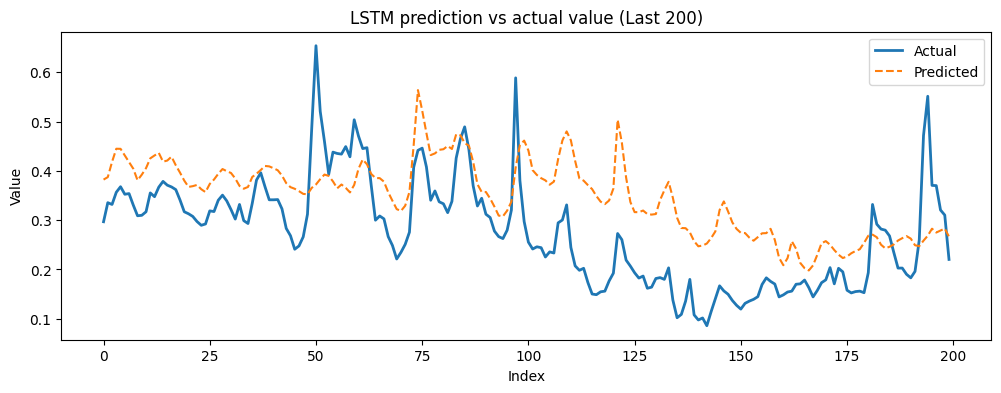

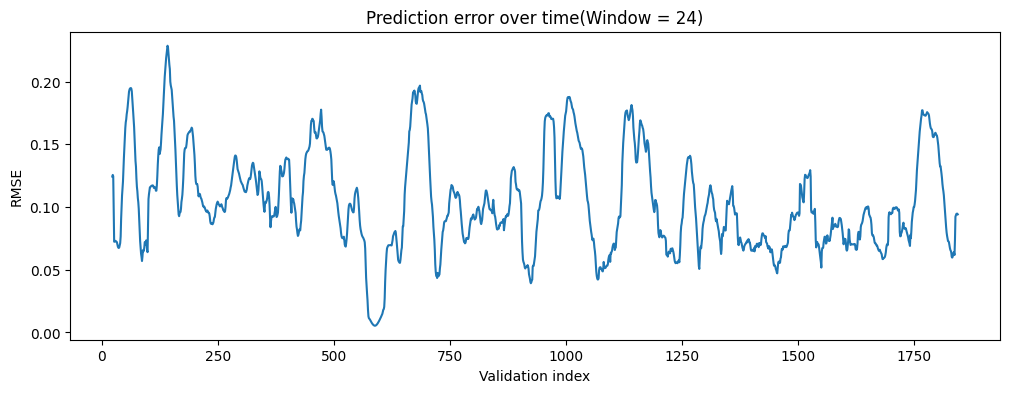

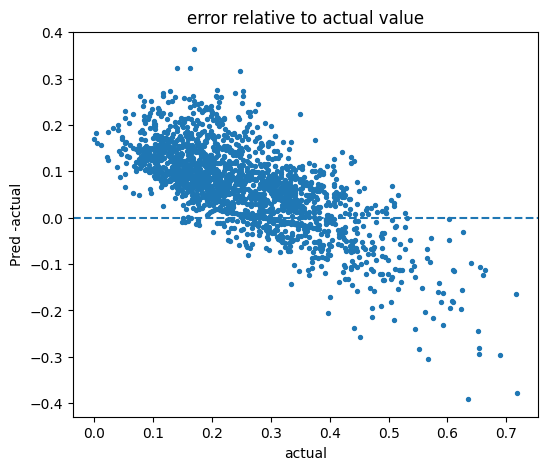

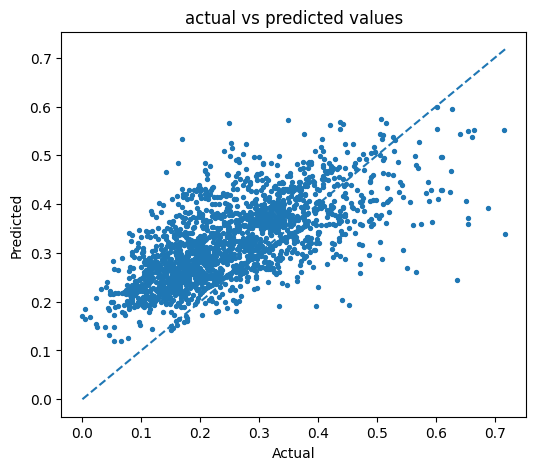

In [85]:
MIN_COUNT = 2
val_arrays=(np.array(pad_sequences([validation_data.iloc[max(0,i):i+seq_length].values for i in range(MIN_COUNT-seq_length, len(validation_data)-seq_length-ph)],dtype="float32")).astype(np.float32))
predictions=model.predict(val_arrays,verbose=0).ravel()
val_labs=(np.array([validation_data.iloc[i+seq_length+ph-1].values[0] for i in range(MIN_COUNT-seq_length, len(validation_data)-seq_length-ph)],dtype=np.float32).ravel())

plot_actual_vs_pred(val_labs, predictions, title="LSTM prediction vs actual value", last_n=200)
plot_rolling_rmse(val_labs, predictions, window=24, title="Prediction error over time")
plot_error_vs_actual(val_labs, predictions, title="error relative to actual value")
plot_parity(val_labs, predictions, title="actual vs predicted values")



In [86]:
autoencoder = Sequential()
autoencoder.add(Input(shape=(seq_length, nb_features)))
autoencoder.add(LSTM(16, return_sequences=False))
autoencoder.add(RepeatVector(seq_length))
autoencoder.add(LSTM(16, return_sequences=True))
autoencoder.add(TimeDistributed(Dense(nb_features)))

optimizer_ae = keras.optimizers.Adam(learning_rate=0.001)
autoencoder.compile(loss="mean squared error", optimizer=optimizer_ae)
autoencoder.summary()


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_25 (LSTM)                  │ (None, 16)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_2 (RepeatVector)  │ (None, 168, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_26 (LSTM)                  │ (None, 168, 16)        │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 168, 1)         │            17 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,281 (12.82 KB)

 Trainable params: 3,281 (12.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
14/14 - 14s - 983ms/step - loss: 0.1682 - val_loss: 0.0099
Epoch 2/100
14/14 - 4s - 317ms/step - loss: 0.0270 - val_loss: 0.0335
Epoch 3/100
14/14 - 5s - 341ms/step - loss: 0.0205 - val_loss: 0.0124
Epoch 4/100
14/14 - 5s - 322ms/step - loss: 0.0195 - val_loss: 0.0198
Epoch 5/100
14/14 - 5s - 348ms/step - loss: 0.0189 - val_loss: 0.0183
Epoch 6/100
14/14 - 4s - 316ms/step - loss: 0.0186 - val_loss: 0.0178
Epoch 7/100
14/14 - 5s - 361ms/step - loss: 0.0185 - val_loss: 0.0188
Epoch 8/100
14/14 - 5s - 338ms/step - loss: 0.0185 - val_loss: 0.0182
Epoch 9/100
14/14 - 4s - 303ms/step - loss: 0.0184 - val_loss: 0.0186
Epoch 10/100
14/14 - 5s - 349ms/step - loss: 0.0183 - val_loss: 0.0185
Epoch 11/100
14/14 - 5s - 333ms/step - loss: 0.0182 - val_loss: 0.0188


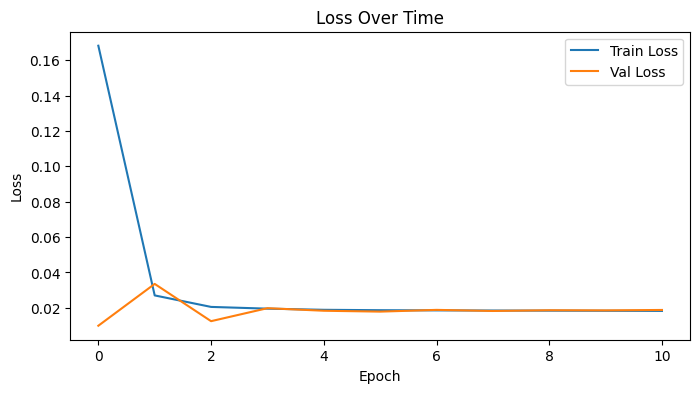

In [88]:
autoencoder.compile(optimizer="adam", loss="mse")
history_ae = autoencoder.fit(
    seq_arrays, seq_arrays, epochs=100, batch_size=500,validation_split=0.05 ,verbose=2,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=10,restore_best_weights=True)]
)
plot_loss(history_ae)

In [89]:
train_recon = autoencoder.predict(seq_arrays, verbose=0)
train_rec_err = np.mean((train_recon - seq_arrays) ** 2, axis=(1, 2))

val_recon = autoencoder.predict(val_arrays, verbose=0)
val_rec_err = np.mean((val_recon - val_arrays) ** 2, axis=(1, 2))

threshold = np.percentile(train_rec_err, 95)
anomaly_idx = np.where(val_rec_err > threshold)[0]

print("Threshold:", threshold)
print("flagged sequences:", len(anomaly_idx))


Threshold: 0.05445402
flagged sequences: 36


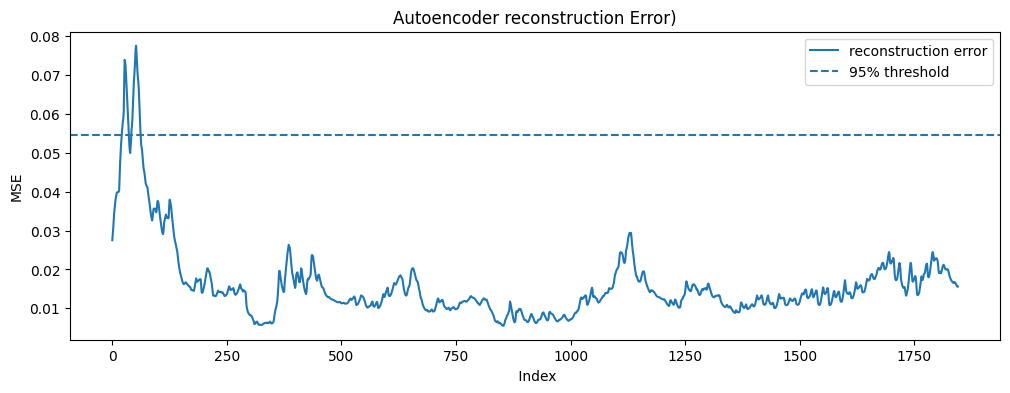

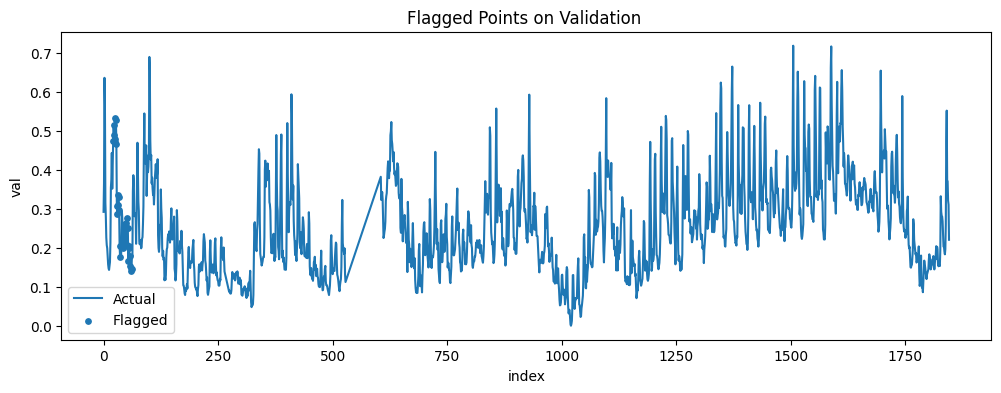

In [93]:
plt.figure(figsize=(12, 4))
plt.plot(val_rec_err, label="reconstruction error")
plt.axhline(threshold, linestyle="--", label="95% threshold")
plt.legend()
plt.title("Autoencoder reconstruction Error)")
plt.xlabel(" Index")
plt.ylabel("MSE")
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(val_labs, label="Actual")
plt.scatter(anomaly_idx, val_labs[anomaly_idx], s=15, label="Flagged")
plt.legend()
plt.title("Flagged Points on Validation ")
plt.xlabel("index")
plt.ylabel("val")
plt.show()


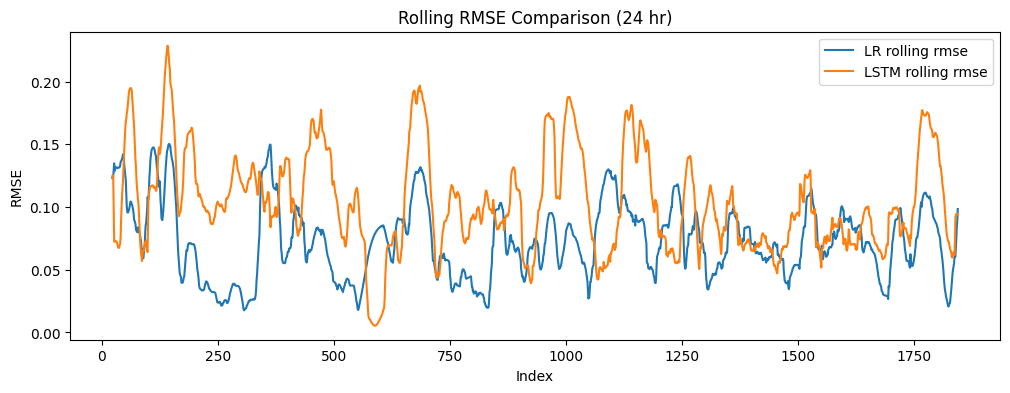

In [91]:
window = 24
pred_1d = np.asarray(predictions).ravel()
true_1d = np.asarray(val_labs).ravel()
lr_1d = np.asarray(lr_comp).ravel()

rmse_lr = np.sqrt(pd.Series((lr_1d - true_1d) ** 2).rolling(window).mean())
rmse_lstm = np.sqrt(pd.Series((pred_1d - true_1d) ** 2).rolling(window).mean())

plt.figure(figsize=(12, 4))
plt.plot(rmse_lr, label="LR rolling rmse")
plt.plot(rmse_lstm, label="LSTM rolling rmse")
plt.legend()
plt.title("Rolling RMSE Comparison (24 hr)")
plt.xlabel("Index")
plt.ylabel("RMSE")
plt.show()


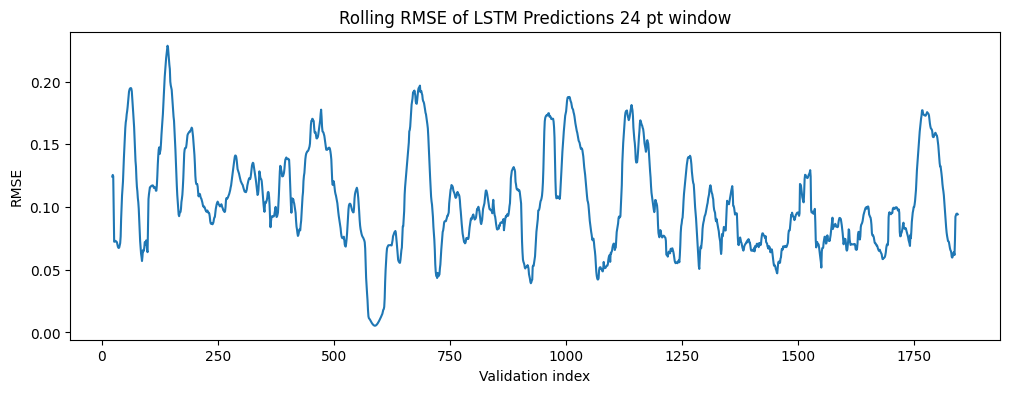

In [92]:
err = (predictions.flatten() - val_labs.flatten())
window = 24
rolling_rmse = pd.Series(err).rolling(window).apply(lambda x: np.sqrt(np.mean(x**2)), raw=True)
plt.figure(figsize=(12,4))
plt.plot(rolling_rmse)
plt.title("Rolling RMSE of LSTM Predictions 24 pt window")
plt.xlabel("Validation index")
plt.ylabel("RMSE")
plt.show()

In [ ]:
"""Load Tableau data, add the NO2 data and save it again"""
tableau = pd.read_csv("../../Data/Tableau.csv")

# push NOx readings and predictions
tableau["PT08.S4(NO2)"] = sensor_values
tableau["NO2_predictions"] = np.concatenate([np.full(len(sensor_values), np.nan), yp_pred[-24:]])

# push drift data
drift = np.concatenate([np.where(train_rec_err > threshold, 1, 0), np.where(val_rec_err > threshold, 1, 0)])
tableau.loc[219: len(tableau)-24, "NO2-drift"] = drift

# and save it
tableau.to_csv("../../Data/Tableau.csv", index=False)